Music Recommendation System using Machine Learning
from Geeks for Geeks: https://www.geeksforgeeks.org/machine-learning/music-recommendation-system-using-machine-learning/

Using "TCC CEDs Music Dataset", contains metadata about songs including genres, artists, lyrics

## 1. Import Libraries and Dataset

In [1]:
# import libraries 
# !pip install pandas 
# !pip install "numpy==1.26.4"
# !pip install scikit-learn seaborn matplotlib


import pandas as pd 
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('tcc_ceds_music.csv')
df.head()

,Unnamed: 0,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,...,sadness,feelings,danceability,loudness,acousticness,instrumentalness,valence,energy,topic,age
0,0,mukesh,mohabbat bhi jhoothi,1950,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,...,0.380299,0.117175,0.357739,0.454119,0.997992,0.901822,0.339448,0.137110,sadness,1.0
1,4,frankie laine,i believe,1950,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,...,0.001284,0.001284,0.331745,0.647540,0.954819,0.000002,0.325021,0.263240,world/life,1.0
2,6,johnnie ray,cry,1950,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,...,0.002770,0.225422,0.456298,0.585288,0.840361,0.000000,0.351814,0.139112,music,1.0
3,10,pérez prado,patricia,1950,pop,kiss lips want stroll charm mambo chacha merin...,54,0.048249,0.001548,0.001548,...,0.225889,0.001548,0.686992,0.744404,0.083935,0.199393,0.775350,0.743736,romantic,1.0
4,12,giorgos papadopoulos,apopse eida oneiro,1950,pop,till darling till matter know till dream live ...,48,0.001350,0.001350,0.417772,...,0.068800,0.001350,0.291671,0.646489,0.975904,0.000246,0.597073,0.394375,romantic,1.0


## 2. EDA

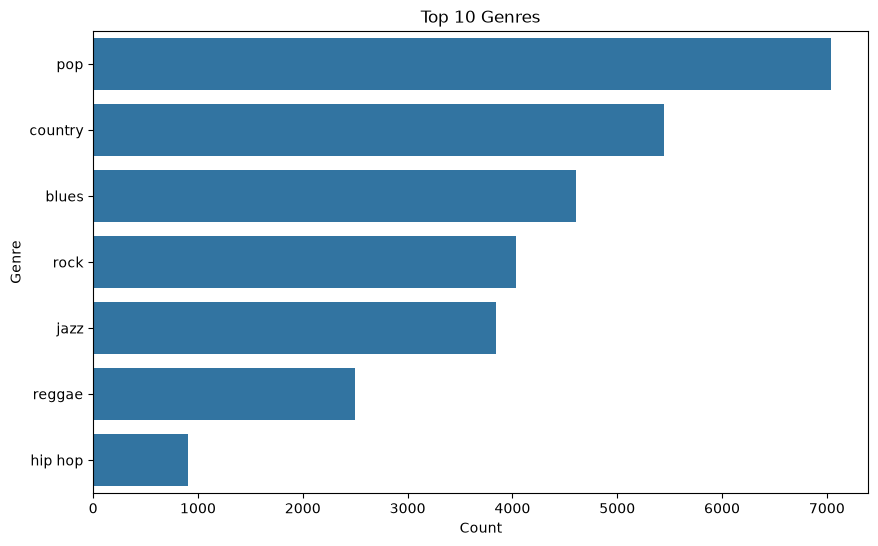

In [3]:
# visualize top 10 genres in dataset to understand diversity of songs

plt.figure(figsize=(10,6))
# plots top 10 genres after ranking them by highest frequency 
sns.countplot(y='genre', data=df, order=df['genre'].value_counts().index[:10]) 

plt.title('Top 10 Genres')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()


/var/folders/46/yc4496mx77g8716fqwx2phsr0000gn/T/ipykernel_53938/3704612194.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artists.values, y=top_artists.index, palette='viridis')


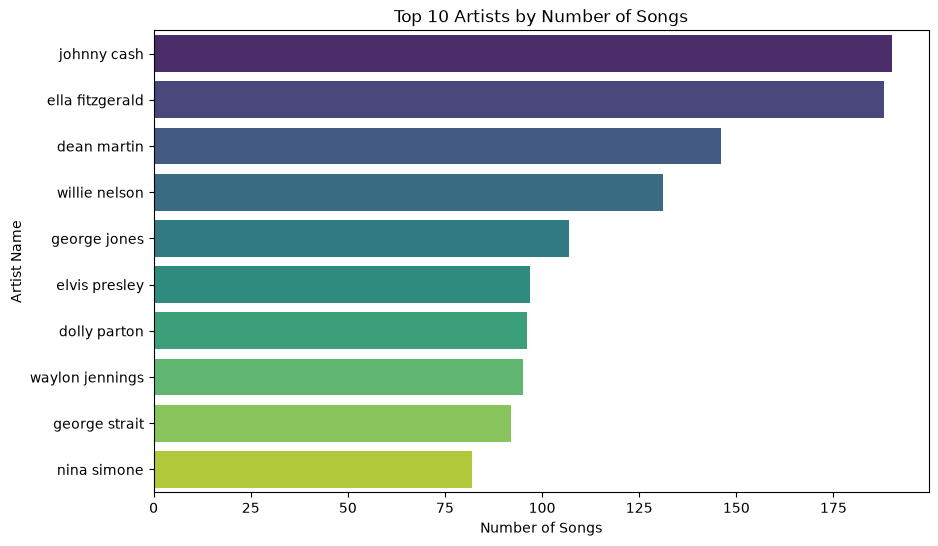

In [4]:
# identify top artists based on the number of songs they have in the dataset
top_artists = df.groupby('artist_name').size().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_artists.values, y=top_artists.index, palette='viridis')

plt.title('Top 10 Artists by Number of Songs')
plt.xlabel('Number of Songs')
plt.ylabel('Artist Name')
plt.show()

/var/folders/46/yc4496mx77g8716fqwx2phsr0000gn/T/ipykernel_53938/102492701.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='pastel')


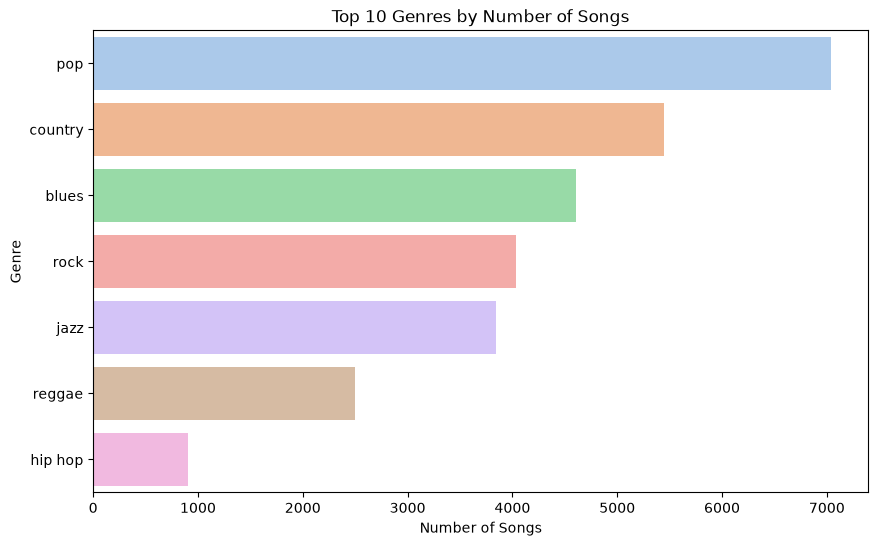

In [5]:
# let me try to replicate this plot using groupby for top genre
top_genres=df.groupby('genre').size().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='pastel')
plt.title('Top 10 Genres by Number of Songs')
plt.xlabel('Number of Songs')
plt.ylabel('Genre')
plt.show()

## 3. Data Preprocessing

To build recommmendation system, we need to preprocess the data by combining relevant features and converting them into numerical vectors

In [6]:
# Combine features,
# concatenate genre, artist_name, and track_name into columns into a single feature called combined_features

df['combined_features'] = (df['genre'].fillna('')+' '+df['artist_name'].fillna('')+ ' '+df['track_name'].fillna(''))
df['combined_features']

0                     pop mukesh mohabbat bhi jhoothi
1                         pop frankie laine i believe
2                                 pop johnnie ray cry
3                            pop pérez prado patricia
4         pop giorgos papadopoulos apopse eida oneiro
                             ...                     
28367                 hip hop mack 10 10 million ways
28368    hip hop m.o.p. ante up (robbin hoodz theory)
28369                      hip hop nine whutcha want?
28370                       hip hop will smith switch
28371                            hip hop jeezy r.i.p.
Name: combined_features, Length: 28372, dtype: str

What is TF-IDF vectorization and how does it work?

Term Frequency-Inverse Document Frequency, used in NLP and highlights the importance of a word to a specific document relative to an entire collection of documents, giving higher weights to rarer words and lower weights to generic words.

TF: Counts how many times a word appears in a document, dividing over the number of words in a document. IDF: divides the total number of documents by the number of documents containing the word. the numerical weight is the product of TF x IDF.

In [7]:
#Vectorize Text Data using TF-IDF Vectorization to convert combined features into numerical vectors

tfidf= TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['combined_features']) # transforms text into features
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 132224 stored elements and shape (28372, 14090)>

In [ ]:
# compute similarity scores
# by computing cosine similarity between songs based on their vetorized features


cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

def get_recommendations(song_title, data, cosine_sim, top_n):

    # get index of song that matches the title
    idx = df[df['track_name']==song_title].index
    
    # song not found
    if len(idx)==0:
        print("Song not found in the dataset!")
        return
    
    idx = idx[0] # if multiple songs found, get the first one

    # computes similarity scores for all songs and sorts them in descending order
    sim_scores=list(enumerate(cosine_sim[idx]))

    sim_scores=sorted(sim_scores, key=lambda x: x[1], reverse=True)

    to_remove = []

    # if artist name in similar songs is same as searched song, remove from sim_scores
    for i in range(len(sim_scores)):
        # print(df.iloc[i[0]].artist_name)
        if(df.iloc[sim_scores[i][0]].artist_name==df.iloc[idx].artist_name):  
            to_remove.append(sim_scores[i])

    for i in to_remove:
        sim_scores.remove(i)    

    # returns top-N most similar songs
    sim_scores=sim_scores[1:top_n+1]

    song_indices = [i[0] for i in sim_scores]

    recommendations = df.iloc[song_indices]

    return recommendations


    


## 4. Generate Recommendations

In [35]:
recommended_songs = get_recommendations('cry', df, cosine_sim, top_n=10)

print(recommended_songs[['track_name', 'artist_name', 'genre']])

                          track_name     artist_name    genre
15294              too many memories  johnnie taylor    blues
14542  there's nothing i wouldn't do  johnnie taylor    blues
14679                         lately  johnnie taylor    blues
13887                     steal away  johnnie taylor    blues
14701             don't make me late  johnnie taylor    blues
12881           baby, we've got love  johnnie taylor    blues
13247  i got to love somebody's baby  johnnie taylor    blues
12882            i need lots of love  johnnie taylor    blues
4957                  when it's over       sugar ray      pop
12340                     get to you     michael ray  country
